# CT Gas Capex Analysis

Data source: Halcyon Gas Power Plant Tracker (24 Aug 2026), covering gas power plant projects across the US. We keep only CT projects with a reported cost ($/kW), then use regression analysis on that data to forecast CT capex from 2026 to 2032.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "runreeds.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

FORECAST_DIR = REPO_ROOT / "CEPM/preprocessing/gas_capex_forecast"

df = pd.read_csv(FORECAST_DIR / "Halcyon_August_CT.csv")
df.head()

,Plant / Unit Name,State,BA Code,Announcement Date,Planned / Operating Year,Technology Type,Capacity (MW),Cost ($/kW),CapEx ($M),Actual vs. Estimated Cost,Dollar Year,Latitude,Longitude,EIA Status,EIA Plant ID,Dollar Year Used,"Cost ($/kW, 2022$)"
0,Thomas Fitzhugh,AR,SWPP,"Feb 26, 2024",-,Simple-Cycle Gas Turbine,140.5,978.947368,93,Estimated,-,35.462382,-93.80493,"Construction complete, but not yet in commerci...",201,2024,913.89
1,Ironwood Power Station,AR,MISO,"Nov 1, 2024",2028,Simple-Cycle Gas Turbine,446.0,1753.000000,782,Estimated,-,34.433826,-92.9042,Regulatory approvals pending. Not under constr...,69750,2024,1636.50
2,Apache Generating Station GT5 and GT6,AZ,WALC,"Oct 1, 2024",2025,Simple-Cycle Gas Turbine,84.0,920.370000,77,Actual,2025,32.0603,-109.8931,Operating,160,2025,837.43
3,Redhawk Plant Expansion,AZ,SRP,"Jul 8, 2024",2028,Simple-Cycle Gas Turbine,397.0,1115.870000,443,Estimated,2024,33.334562,-112.8406,"Under construction, less than or equal to 50 p...",55455,2024,1041.71
4,Black Mountain Expansion Project,AZ,TEPC,"Mar 8, 2024",2027,Simple-Cycle Gas Turbine,200.0,1090.000000,218,Estimated,-,35.03550381,-114.1595616,-,-,2024,1017.56


## Data Cleaning

Drop two types of outliers before fitting anything:
- Projects with a planned/operating year **after 2032**
- Projects with a cost **above $3000/kW**

In [2]:
# Use the dollar-year-normalized cost (see data_cleaning_gas.ipynb) instead of the raw, mixed-dollar-year cost
df["Cost ($/kW)"] = pd.to_numeric(df["Cost ($/kW, 2022$)"], errors="coerce")
df["Planned / Operating Year"] = pd.to_numeric(df["Planned / Operating Year"], errors="coerce")

# Clean data: drop rows with year after 2032 or cost above 3000 $/kW (outliers)
df = df[(df["Planned / Operating Year"] <= 2032) & (df["Cost ($/kW)"] <= 3000)]
df.shape

(35, 17)

## Scatter plot: Cost vs. Year

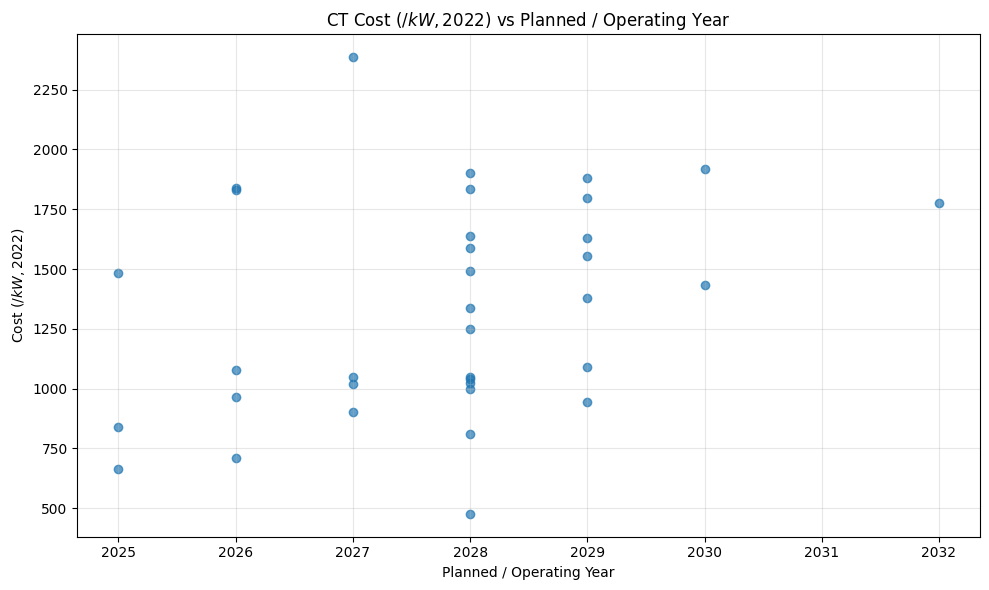

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"], alpha=0.7)
ax.set_xlabel("Planned / Operating Year")
ax.set_ylabel("Cost ($/kW, 2022$)")
ax.set_title("CT Cost ($/kW, 2022$) vs Planned / Operating Year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Regression (all data)


CT — 35 plants
  Year  : 2025–2032  (mean 2027.8)
  Cost  : $476–$2386 /kW, 2022$  (mean $1332, std $449)
  Regression: slope=94.7 $/kW/yr,  R²=0.105,  p=0.057


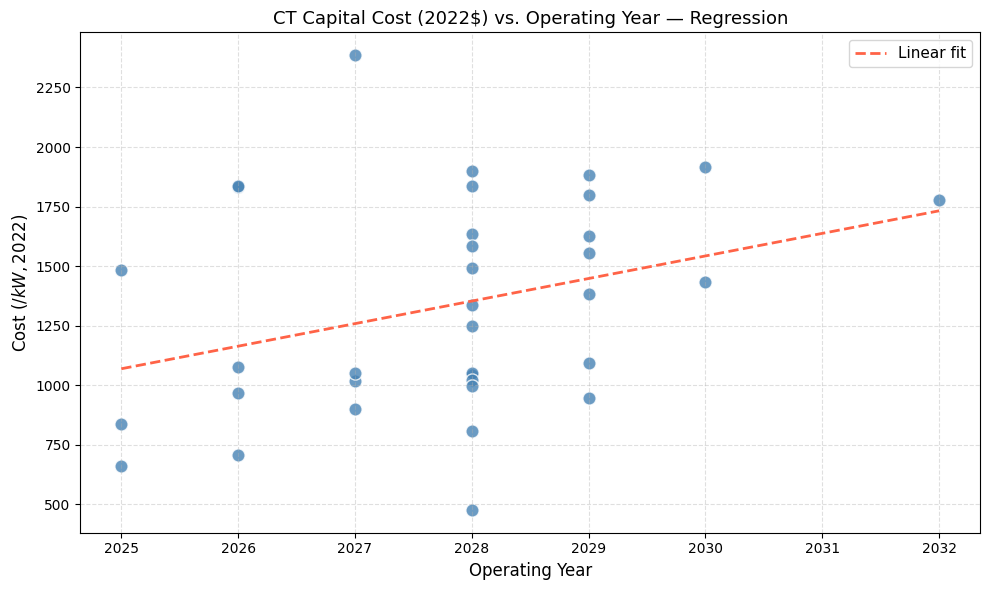

In [4]:
slope, intercept, r, p, stderr = linregress(df["Planned / Operating Year"], df["Cost ($/kW)"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"],
           color="steelblue", alpha=0.8, edgecolors="white", s=90)

x_range = np.linspace(df["Planned / Operating Year"].min(), df["Planned / Operating Year"].max(), 100)
ax.plot(x_range, intercept + slope * x_range,
        color="tomato", linewidth=2, linestyle="--", label="Linear fit")

print(f"\nCT — {len(df)} plants")
print(f"  Year  : {df['Planned / Operating Year'].min():.0f}–{df['Planned / Operating Year'].max():.0f}  (mean {df['Planned / Operating Year'].mean():.1f})")
print(f"  Cost  : ${df['Cost ($/kW)'].min():.0f}–${df['Cost ($/kW)'].max():.0f} /kW, 2022$  (mean ${df['Cost ($/kW)'].mean():.0f}, std ${df['Cost ($/kW)'].std():.0f})")
print(f"  Regression: slope={slope:.1f} $/kW/yr,  R²={r**2:.3f},  p={p:.3f}")

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW, 2022$)", fontsize=12)
ax.set_title("CT Capital Cost (2022$) vs. Operating Year — Regression", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [5]:
# Extract regression statistics
regression_stats = pd.DataFrame([{
    "n_plants": len(df),
    "slope_$/kW_per_yr": slope,
    "intercept_$/kW": intercept,
    "r_squared": r**2,
    "p_value": p,
    "std_err": stderr,
}])
regression_stats

,n_plants,slope_$/kW_per_yr,intercept_$/kW,r_squared,p_value,std_err
0,35,94.739715,-190778.914733,0.105088,0.057454,48.12707



We fit `Cost ($/kW) = intercept + slope * Year` and get back:

- **p = 0.015 < 0.05** → this trend **is statistically significant**

In [6]:
# Regression forecast 2026-2032
years = np.arange(2026, 2033)
forecast = pd.DataFrame({
    "Year": years,
    "Cost_$/kW": np.round(intercept + slope * years, 1),
})
forecast.to_csv(FORECAST_DIR / "ct_regression_forecast.csv", index=False)
forecast

,Year,Cost_$/kW
0,2026,1163.7
1,2027,1258.5
2,2028,1353.2
3,2029,1448.0
4,2030,1542.7
5,2031,1637.4
6,2032,1732.2


Unlike CCGT, we keep a **single forecast** for CT. This single regression forecast is exported to `ct_regression_forecast.csv`, which `gas_CAPEX_update.ipynb` then uses to update the Gas-CT `capcost` values in all 3 ATB scenario files (the CT input stays the same across `v1_low`, `v2_high`, `v3_all` — only the CCGT side varies).